找到 10 个图像文件

正在处理: 462_22.png


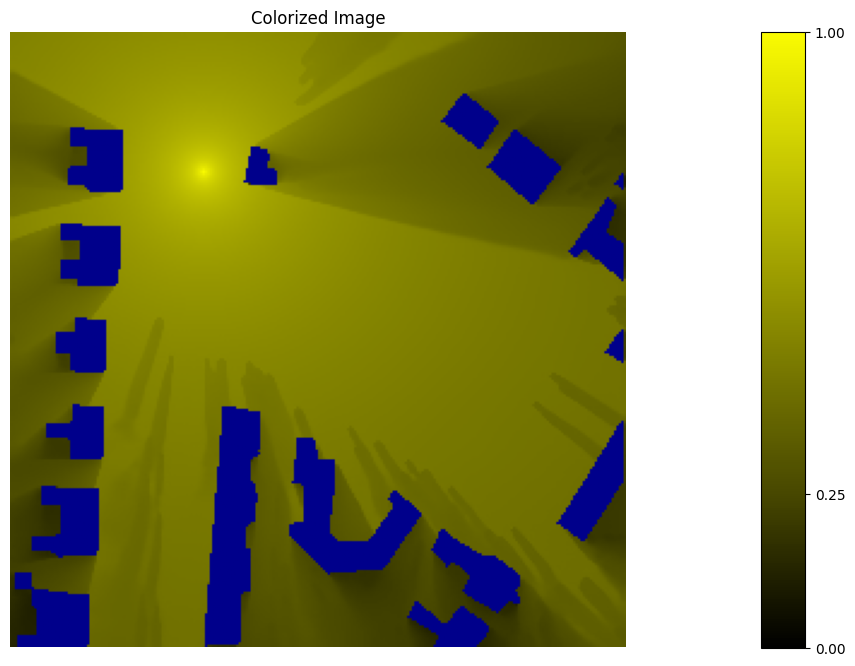

颜色图像已保存至: /home/zqm1/workspace2/RadioMamba-main/src/select_test/mambacars/462_22_colorized.png

正在处理: 419_63.png


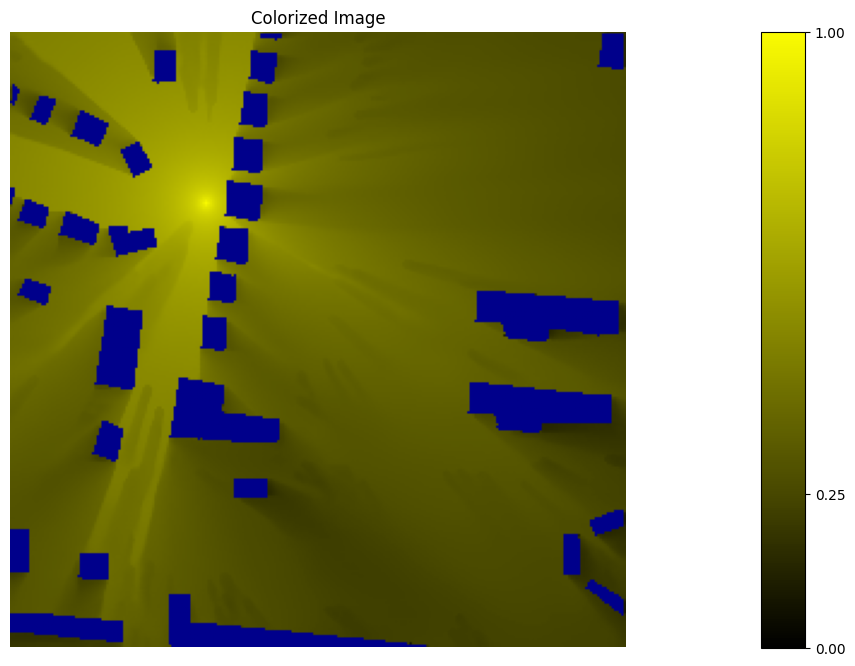

颜色图像已保存至: /home/zqm1/workspace2/RadioMamba-main/src/select_test/mambacars/419_63_colorized.png

正在处理: 65_60.png


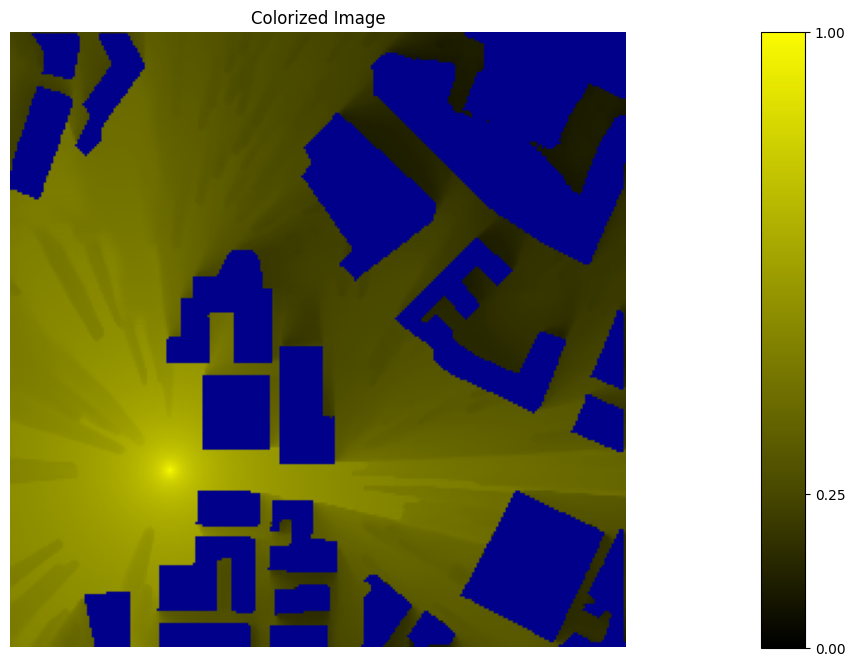

颜色图像已保存至: /home/zqm1/workspace2/RadioMamba-main/src/select_test/mambacars/65_60_colorized.png

正在处理: 664_54.png


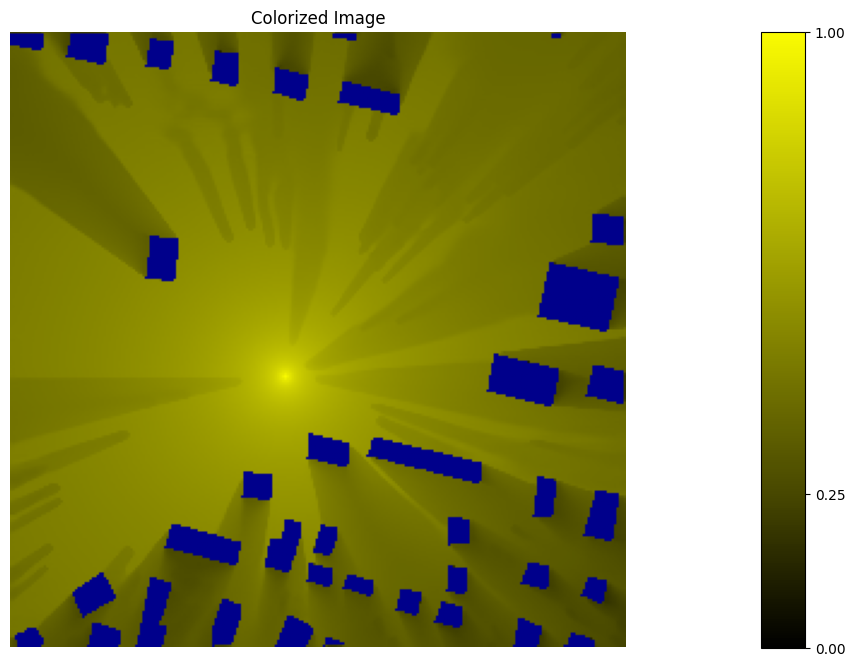

颜色图像已保存至: /home/zqm1/workspace2/RadioMamba-main/src/select_test/mambacars/664_54_colorized.png

正在处理: 511_28.png


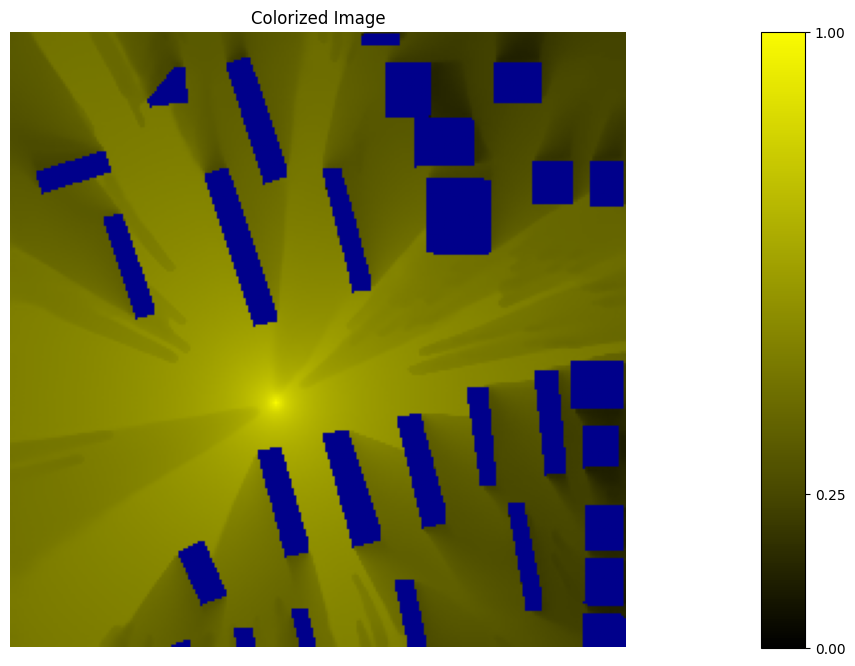

颜色图像已保存至: /home/zqm1/workspace2/RadioMamba-main/src/select_test/mambacars/511_28_colorized.png

正在处理: 467_74.png


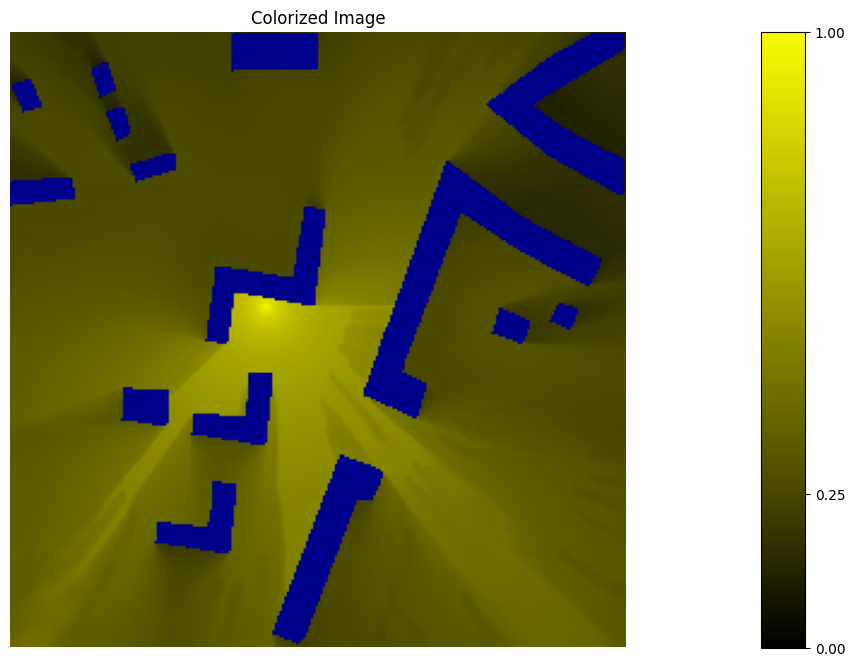

颜色图像已保存至: /home/zqm1/workspace2/RadioMamba-main/src/select_test/mambacars/467_74_colorized.png

正在处理: 367_59.png


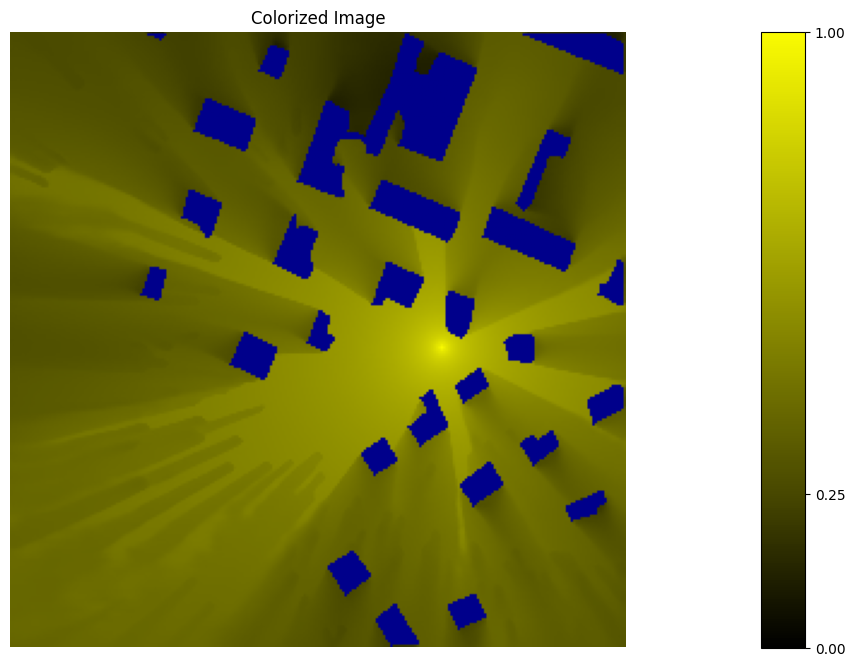

颜色图像已保存至: /home/zqm1/workspace2/RadioMamba-main/src/select_test/mambacars/367_59_colorized.png

正在处理: 289_40.png


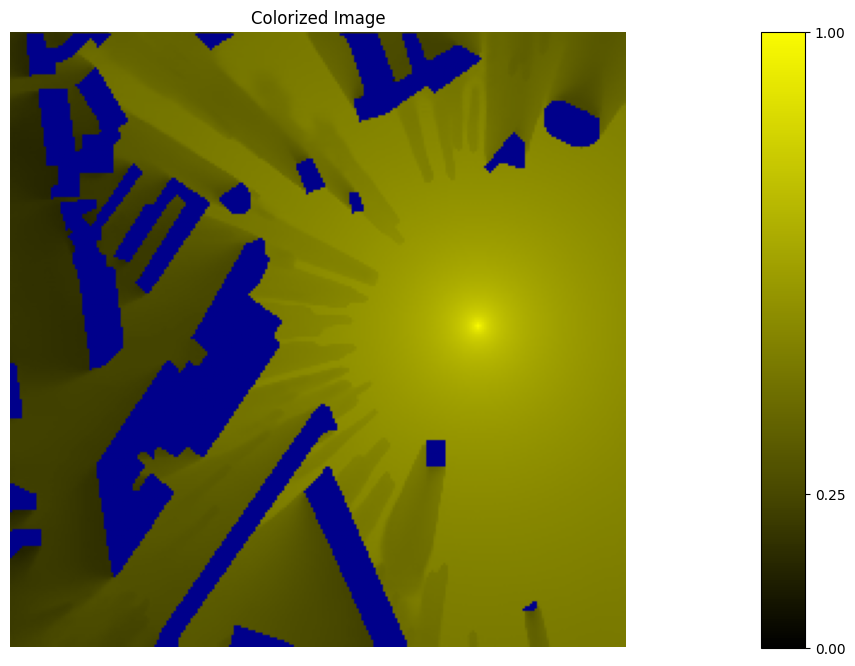

颜色图像已保存至: /home/zqm1/workspace2/RadioMamba-main/src/select_test/mambacars/289_40_colorized.png

正在处理: 402_6.png


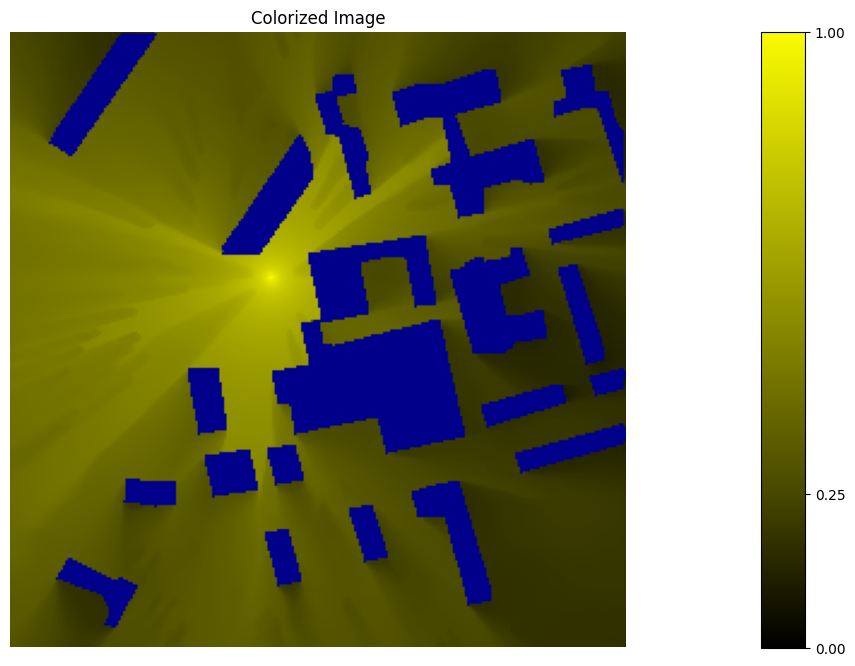

颜色图像已保存至: /home/zqm1/workspace2/RadioMamba-main/src/select_test/mambacars/402_6_colorized.png

正在处理: 455_52.png


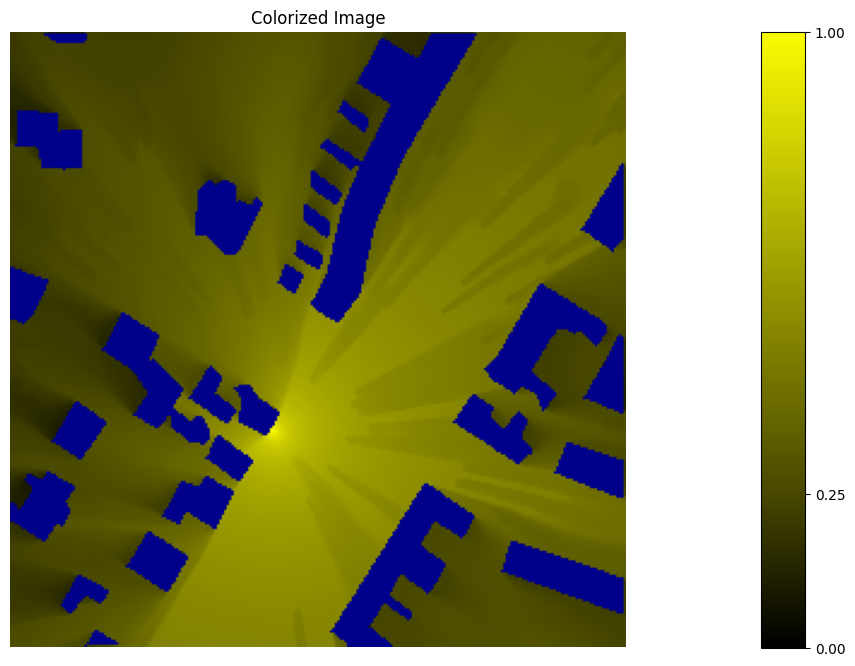

颜色图像已保存至: /home/zqm1/workspace2/RadioMamba-main/src/select_test/mambacars/455_52_colorized.png

批量处理完成！共处理 10 个文件


In [30]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib import colors as clr
from matplotlib.cm import ScalarMappable
from matplotlib.gridspec import GridSpec

def create_colormap():
    """
    创建一个名为 'mycolor' 的自定义颜色映射，具有指定的颜色分布。
    """
    return clr.LinearSegmentedColormap.from_list('mycolor', 
                                                 [(0, '#000000'),
                                                  (0.25, '#484800'),
                                                  (1, '#FAFB01')], N=256)

def colorize_image(image_path, gap=0.3, threshold=None, custom_color='#FF0000'):
    """
    将灰度图像上色，显示带有自定义间隔的垂直颜色条，并对高于阈值的区域应用自定义颜色。

    参数:
    - image_path (str): 图像文件的路径。
    - gap (float): 图像与颜色条之间的间隔比例，范围通常在 0 到 1 之间。默认为 0.3。
    - threshold (float, 可选): 归一化灰度值的阈值，范围在 0 到 1 之间。如果设置，所有高于该阈值的像素将被替换为自定义颜色。默认为 None。
    - custom_color (str 或 tuple): 用于替换高于阈值区域的颜色。可以是十六进制字符串（如 '#FF0000'）或 RGB/RGBA 元组（如 (1, 0, 0)）。
    """
    try:
        # 加载灰度图像
        grayscale_image = Image.open(image_path).convert('L')
        grayscale_array = np.array(grayscale_image) / 255.0  # 归一化数组

        # 创建自定义颜色映射
        my_colormap = create_colormap()
        
        # 应用颜色映射到灰度图像
        colorized_image = my_colormap(grayscale_array)  # 形状为 (H, W, 4)，RGBA

        # 如果设置了阈值，则替换高于阈值的区域颜色
        if threshold is not None:
            if not (0 <= threshold <= 1):
                raise ValueError("阈值必须在 0 到 1 之间。")
            
            # 将自定义颜色转换为 RGBA
            custom_rgba = clr.to_rgba(custom_color)
            
            # 创建一个布尔掩码，标识灰度值<阈值的像素
            mask = grayscale_array <= threshold
            
            # 使用布尔掩码将颜色化图像中对应像素的颜色替换为自定义颜色
            colorized_image[mask] = custom_rgba

        # 创建一个新的图形
        fig = plt.figure(figsize=(12, 8))

        # 使用 GridSpec 来定义图像和颜色条的布局
        # 这里，我们创建一个包含两列的网格，第二列用于颜色条
        gs = GridSpec(1, 2, width_ratios=[20, 1], wspace=gap)  # wspace 控制图像与颜色条之间的水平间隔

        # 定义图像的子图
        ax_image = fig.add_subplot(gs[0])
        ax_image.imshow(colorized_image)
        ax_image.set_title('Colorized Image')
        ax_image.axis('off')  # 关闭坐标轴显示

        # 定义颜色条的子图
        ax_colorbar = fig.add_subplot(gs[1])

        # 创建 ScalarMappable 对象，用于颜色条
        sm = ScalarMappable(cmap=my_colormap, norm=plt.Normalize(vmin=0, vmax=1))
        sm.set_array([])  # 对于某些旧版本的 matplotlib 需要

        # 使用 ScalarMappable 创建垂直颜色条
        # colorbar = plt.colorbar(sm, cax=ax_colorbar, orientation='vertical', label='Grayscale Intensity')
        colorbar = plt.colorbar(sm, cax=ax_colorbar, orientation='vertical')
        colorbar.set_ticks([0, 0.25, 1])
        # colorbar.set_ticklabels(['Black', 'Dark Yellow', 'Yellow'])

        # # 如果设置了阈值，添加自定义颜色的图例标识
        # if threshold is not None:
        #     # 添加一个自定义的颜色块到颜色条的顶部或底部，以表示自定义颜色
        #     from matplotlib.patches import Patch
        #     import matplotlib.lines as mlines

        #     # 创建一个额外的图例项
        #     custom_patch = Patch(facecolor=custom_color, edgecolor='none', label='Custom Color Above Threshold')

        #     # 获取当前颜色条的 Axes 对象
        #     cbar_ax = colorbar.ax

        #     # 添加图例
        #     cbar_ax.legend(handles=[custom_patch], loc='upper right', frameon=False)

        plt.show()
        output_path = image_path.replace('.png', '_colorized.png')
        Image.fromarray((colorized_image[:, :, :3] * 255).astype(np.uint8)).save(output_path)
        print(f"颜色图像已保存至: {output_path}")

    except FileNotFoundError:
        print(f"错误: 文件路径 {image_path} 不存在。")
    except IOError:
        print(f"错误: 无法打开文件 {image_path}。请检查文件格式并重试。")
    except ValueError as ve:
        print(f"错误: {ve}")

# 示例用法
import os
import glob

# 批量处理目录下的所有图像文件
if __name__ == "__main__":
    # 目标目录
    target_dir = '/home/zqm1/workspace2/RadioMamba-main/src/select_test/mambacars'
    
    # 获取目录下所有PNG文件
    image_files = glob.glob(os.path.join(target_dir, '*.png'))
    
    print(f"找到 {len(image_files)} 个图像文件")
    
    # 处理每个图像文件
    for image_path in image_files:
        print(f"\n正在处理: {os.path.basename(image_path)}")
        try:
            colorize_image(
                image_path=image_path,
                gap=0.,               # 自定义间隔
                threshold=0.08,      # 设置阈值为 0.08
                custom_color='#00008B' # 自定义颜色
            )
        except Exception as e:
            print(f"处理 {os.path.basename(image_path)} 时出错: {e}")
    
    print(f"\n批量处理完成！共处理 {len(image_files)} 个文件")

In [31]:
import os
import shutil
import re

# 源目录
target_dir1 = "/home/zqm1/workspace2/RadioMamba-main/src/select_test/mambacars"
car_dir = "/home/zqm1/dataset/RadioMapSeer/png/cars"
output_dir = "/home/zqm1/workspace2/RadioMamba-main/src/select_test/cars"

# 确保目标目录存在
os.makedirs(output_dir, exist_ok=True)

# 正则用于提取文件名前面的数字
pattern = re.compile(r'^(\d+)_')

# 遍历 target_dir1 中的文件
for file in os.listdir(target_dir1):
    match = pattern.match(file)
    if match:
        number = match.group(1)
        car_file_name = f"{number}.png"
        car_file_path = os.path.join(car_dir, car_file_name)
        if os.path.isfile(car_file_path):
            # 复制到输出目录
            shutil.copy(car_file_path, os.path.join(output_dir, car_file_name))
            print(f"已复制: {car_file_name}")
        else:
            print(f"未找到: {car_file_name}")


已复制: 462.png
已复制: 419.png
已复制: 289.png
已复制: 65.png
已复制: 402.png
已复制: 65.png
已复制: 511.png
已复制: 462.png
已复制: 467.png
已复制: 664.png
已复制: 511.png
已复制: 467.png
已复制: 367.png
已复制: 289.png
已复制: 664.png
已复制: 367.png
已复制: 402.png
已复制: 455.png
已复制: 419.png
已复制: 455.png


In [32]:
import os
from PIL import Image
import numpy as np

# 输入和输出目录
input_dir = "/home/zqm1/workspace2/RadioMamba-main/src/select_test/cars"
output_dir = "/home/zqm1/workspace2/RadioMamba-main/src/select_test/mambacars"  # 也可以另存一个目录

# 遍历处理所有 PNG 文件
for file_name in os.listdir(input_dir):
    if not file_name.lower().endswith(".png"):
        continue

    file_path = os.path.join(input_dir, file_name)
    img = Image.open(file_path).convert("L")  # 转换为灰度图
    arr = np.array(img)

    # 创建一个空的 RGBA 图像数组
    rgba = np.zeros((arr.shape[0], arr.shape[1], 4), dtype=np.uint8)

    # 设置条件：255变为红色，其余透明
    mask = (arr == 255)
    rgba[mask] = [255, 0, 0, 255]   # 红色 + 不透明
    rgba[~mask] = [0, 0, 0, 0]      # 全透明

    # 保存为 RGBA 图像
    out_img = Image.fromarray(rgba, mode='RGBA')
    out_img.save(os.path.join(output_dir, file_name))

    print(f"已处理: {file_name}")

已处理: 511.png
已处理: 455.png
已处理: 367.png
已处理: 467.png
已处理: 65.png
已处理: 419.png
已处理: 664.png
已处理: 462.png
已处理: 402.png
已处理: 289.png


In [33]:
import os
from PIL import Image

# 文件夹路径
dpm_dir = "/home/zqm1/workspace2/RadioMamba-main/src/select_test/mambacars"
car_dir = "/home/zqm1/workspace2/RadioMamba-main/src/select_test/mambacars"
output_dir = dpm_dir  # 你可以替换成另一个文件夹以保存结果

# 遍历 DPM 文件夹中的文件
for file_name in os.listdir(dpm_dir):
    if not file_name.lower().endswith(".png"):
        continue

    # 提取前缀数字，例如 455_52.png -> 455
    prefix = file_name.split("_")[0]
    car_filename = f"{prefix}.png"
    car_path = os.path.join(car_dir, car_filename)
    dpm_path = os.path.join(dpm_dir, file_name)

    if not os.path.exists(car_path):
        print(f"未找到对应的车图: {car_filename}")
        continue

    # 打开两张图片
    dpm_img = Image.open(dpm_path).convert("RGBA")
    car_img = Image.open(car_path).convert("RGBA")

    # 尺寸不一致时，自动调整 car 图大小
    if dpm_img.size != car_img.size:
        car_img = car_img.resize(dpm_img.size)

    # 图像叠加：car 图覆盖在 dpm 图上
    blended = Image.alpha_composite(dpm_img, car_img)

    # 保存覆盖结果
    save_path = os.path.join(output_dir, file_name)
    blended.save(save_path)
    print(f"已覆盖合成并保存: {save_path}")


未找到对应的车图: 511.png.png
未找到对应的车图: 455.png.png
已覆盖合成并保存: /home/zqm1/workspace2/RadioMamba-main/src/select_test/mambacars/462_22.png
未找到对应的车图: 367.png.png
已覆盖合成并保存: /home/zqm1/workspace2/RadioMamba-main/src/select_test/mambacars/419_63.png
已覆盖合成并保存: /home/zqm1/workspace2/RadioMamba-main/src/select_test/mambacars/289_40_colorized.png
未找到对应的车图: 467.png.png
已覆盖合成并保存: /home/zqm1/workspace2/RadioMamba-main/src/select_test/mambacars/65_60_colorized.png
已覆盖合成并保存: /home/zqm1/workspace2/RadioMamba-main/src/select_test/mambacars/402_6_colorized.png
已覆盖合成并保存: /home/zqm1/workspace2/RadioMamba-main/src/select_test/mambacars/65_60.png
已覆盖合成并保存: /home/zqm1/workspace2/RadioMamba-main/src/select_test/mambacars/511_28_colorized.png
已覆盖合成并保存: /home/zqm1/workspace2/RadioMamba-main/src/select_test/mambacars/462_22_colorized.png
已覆盖合成并保存: /home/zqm1/workspace2/RadioMamba-main/src/select_test/mambacars/467_74_colorized.png
已覆盖合成并保存: /home/zqm1/workspace2/RadioMamba-main/src/select_test/mambacars/664_54.png
已覆盖合成

In [9]:
import os
import shutil

# 源目录
dir1 = "/home/DataDisk/qmzhang/RadioMapSeer/gain/DPM"
dir2 = "/home/DataDisk/qmzhang/select/radiounet/DPM"

# 交集文件保存路径
output_dir = "/home/DataDisk/qmzhang/select/gt/DPM"
os.makedirs(output_dir, exist_ok=True)

# 获取两个目录中的文件名集合
files1 = set(os.listdir(dir1))
files2 = set(os.listdir(dir2))

# 找出两个目录中文件名的交集
common_files = files1 & files2

# 拷贝交集文件到新目录
for filename in common_files:
    src_path = os.path.join(dir1, filename)
    dst_path = os.path.join(output_dir, filename)
    shutil.copy(src_path, dst_path)

print(f"共找到 {len(common_files)} 个交集文件，已保存到 {output_dir}")

共找到 13 个交集文件，已保存到 /home/DataDisk/qmzhang/select/gt/DPM


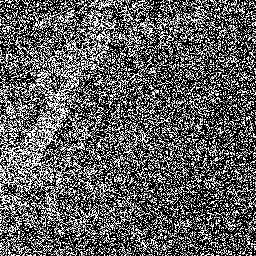

In [16]:
import torch
from torchvision import transforms
from PIL import Image

# 加载图像
img_path = "/home/DataDisk/RadioMap_3D_small/pathloss/h1/438_X121_Y51.png"
image = Image.open(img_path).convert('L')  # 确保图像是灰度图

# 转换为Tensor
transform = transforms.ToTensor()
image_tensor = transform(image)

# 创建噪声
noise = torch.randn_like(image_tensor) * 1  # 0.1是噪声的强度

# 将噪声添加到图像
image_tensor += noise

# 防止值超出范围 [0, 1]
image_tensor = torch.clamp(image_tensor, 0, 1)

# 将图像从Tensor转换回PIL图像
transform_back = transforms.ToPILImage()
noisy_image = transform_back(image_tensor)

# 显示加噪声后的图像
noisy_image.show()
